# UAE E-Commerce Fraud Detection — Capstone Project
# IBT x GGateway Data Science & ML Bootcamp
# Track: Supervised Learning (Binary Classification)
# Goal: Detect fraudulent transactions before they are processed, minimising financial loss to merchants.

# Metric: ROC-AUC (handles class imbalance well)
# Dataset: uae_ecom_fraud_100k.csv  — 100,000 transactions



# Notebook sections
#   1.  Imports & configuration
#   2.  Load data
#   3.  Data dictionary & quality check
#   4.  Data cleaning
#   5.  Signal fix  (synthetic-data correction)
#   6.  Exploratory data analysis (EDA)
#   7.  Feature engineering
#   8.  Train / val / test split
#   9.  Baseline model  (Logistic Regression)
#   10. Improved model  (LightGBM)
#   11. Champion model  (XGBoost)
#   12. Model comparison
#   13. Final evaluation & threshold tuning
#   14. Cross-validation
#   15. Conclusions


In [45]:
# ─────────────────────────────────────────────────────────────
# 1. Imports & configuration
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_val_score)
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics        import (roc_auc_score,
                                    classification_report,
                                    f1_score,
                                    RocCurveDisplay,
                                    ConfusionMatrixDisplay)
from lightgbm import LGBMClassifier
from xgboost  import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# Plot style — dark theme consistent with EDA outputs
plt.rcParams.update({
    "figure.facecolor" : "#0f1117",
    "axes.facecolor"   : "#1a1d27",
    "axes.edgecolor"   : "#2e3248",
    "axes.labelcolor"  : "#c8ccd8",
    "xtick.color"      : "#8b90a0",
    "ytick.color"      : "#8b90a0",
    "text.color"       : "#e2e4ee",
    "grid.color"       : "#2e3248",
    "grid.linewidth"   : 0.6,
    "axes.grid"        : True,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})
RED, BLUE, GREEN, AMBER = "#e05252", "#4a90d9", "#4caf7d", "#f0a443"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [46]:
# ─────────────────────────────────────────────────────────────
# 2. Load data
# ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv("uae_ecom_fraud_100k.csv")
df     = df_raw.copy()

print(f"Dataset shape   : {df.shape}")
print(f"Fraud rate      : {df['is_fraud'].mean():.2%}")
print(f"Null values     : {df.isnull().sum().sum()}")


Dataset shape   : (100000, 36)
Fraud rate      : 8.21%
Null values     : 0


In [47]:
# ─────────────────────────────────────────────────────────────
# 3. Data dictionary & quality check
# ─────────────────────────────────────────────────────────────
# Each row represents one e-commerce transaction.
# Key columns:
#   amount_aed            — transaction value in UAE dirhams
#   ip_risk_score         — 0-100 risk score assigned to the IP
#   user_account_age_days — days since account was created
#   card_age_days         — days since card was issued
#   transactions_last_1h  — velocity: txns in last hour
#   transactions_last_24h — velocity: txns in last 24 hours
#   fraud_flag_*          — rule-based flags (pre-computed)
#   is_fraud              — target: 1 = fraud, 0 = legitimate

print("\n--- Class distribution ---")
print(df["is_fraud"].value_counts())

print("\n--- Constant or near-constant columns ---")
for col in df.columns:
    if df[col].nunique() <= 1:
        print(f"  DEAD (constant) : {col}")
    elif df[col].dtype != "object":
        top = df[col].value_counts(normalize=True).iloc[0]
        if top > 0.999:
            print(f"  NEAR-CONSTANT   : {col}  ({top:.1%})")

print("\n--- Impossible values ---")
print(f"  user_account_age_days min : {df['user_account_age_days'].min()}")
print("  <- negative days are impossible, will be fixed in cleaning")

print("\n--- Initial signal strength (single-feature AUC) ---")
for col in ["ip_risk_score", "fraud_flag_ip",
            "fraud_flag_prev_cb", "transactions_last_1h"]:
    try:
        s = roc_auc_score(df["is_fraud"], df[col])
        s = max(s, 1 - s)
        print(f"  {col:<30}: {s:.4f}")
    except Exception:
        pass
print("  <- all < 0.65  =>  dataset has artificially weak signals")




--- Class distribution ---
is_fraud
0    91789
1     8211
Name: count, dtype: int64

--- Constant or near-constant columns ---
  DEAD (constant) : currency
  NEAR-CONSTANT   : transactions_last_1h  (100.0%)
  DEAD (constant) : fraud_flag_velocity
  DEAD (constant) : data_source

--- Impossible values ---
  user_account_age_days min : -365
  <- negative days are impossible, will be fixed in cleaning

--- Initial signal strength (single-feature AUC) ---
  ip_risk_score                 : 0.6192
  fraud_flag_ip                 : 0.5185
  fraud_flag_prev_cb            : 0.5376
  transactions_last_1h          : 0.5001
  <- all < 0.65  =>  dataset has artificially weak signals


In [48]:
# ─────────────────────────────────────────────────────────────
# 4. Data cleaning
# Decision: we start from the raw copy so the cleaning
# steps are transparent and reproducible.
# ─────────────────────────────────────────────────────────────
df = df_raw.copy()
df = df.dropna(subset=["is_fraud"]).copy()
df["is_fraud"] = df["is_fraud"].astype(int)

# 4-A  Fill missing values
# Numeric  → median  (robust to skew)
# Categorical → mode (most frequent)
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)
print(f"\n[Cleaning] Nulls after imputation : {df.isnull().sum().sum()}")

# 4-B  Drop non-informative columns
# identifiers and timestamps carry no predictive signal
drop_cols = ["transaction_id", "user_id", "ip_address",
             "data_source", "currency", "timestamp_utc"]
drop_cols = [c for c in drop_cols if c in df.columns]

# also drop any remaining object / timestamp columns
extra = [c for c in df.columns
         if c not in drop_cols and c != "is_fraud"
         and (df[c].dtype == "object"
              or "timestamp" in c.lower()
              or "date" in c.lower())]
drop_cols += extra
df.drop(columns=drop_cols, inplace=True, errors="ignore")
print(f"[Cleaning] Dropped columns        : {drop_cols}")
print(f"[Cleaning] Shape after drop       : {df.shape}")

# 4-C  Encode remaining categorical columns
cat_cols = df.select_dtypes("object").columns.tolist()
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
if cat_cols:
    print(f"[Cleaning] Label-encoded          : {cat_cols}")

# 4-D  Drop completely constant columns (now all numeric)
const = [c for c in df.columns
         if c != "is_fraud" and df[c].nunique() <= 1]
if const:
    df.drop(columns=const, inplace=True)
    print(f"[Cleaning] Constant columns dropped: {const}")

# 4-E  Winsorize skewed financial columns at 1 % / 99 %
# We skip binary flags and velocity counters — clipping
# those would destroy their meaning.
SKIP_WIN = ["is_fraud", "shipping_billing_match", "card_present",
            "card_country_match", "user_is_high_risk", "odd_hour",
            "fraud_flag_ip", "fraud_flag_mismatch",
            "fraud_flag_new_account", "fraud_flag_prev_cb",
            "fraud_flag_odd_hour", "fraud_flag_velocity",
            "transactions_last_1h", "transactions_last_24h",
            "user_prev_chargebacks"]

for col in df.select_dtypes(include=[np.number]).columns:
    if col in SKIP_WIN:
        continue
    try:
        if abs(df[col].skew()) > 3:
            lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
            if lo < hi:
                df[col] = df[col].clip(lo, hi)
    except Exception:
        pass
print("[Cleaning] Winsorize complete")

# 4-F  Fix impossible values
neg = (df["user_account_age_days"] < 0).sum()
df["user_account_age_days"] = df["user_account_age_days"].abs()
print(f"[Cleaning] Fixed {neg} negative account-age values")
print(f"[Cleaning] Final clean shape      : {df.shape}")




[Cleaning] Nulls after imputation : 0
[Cleaning] Dropped columns        : ['transaction_id', 'user_id', 'ip_address', 'data_source', 'currency', 'timestamp_utc', 'payment_method', 'device_type', 'browser', 'merchant_category', 'shipping_city', 'billing_city', 'bin_country', 'email_domain']
[Cleaning] Shape after drop       : (100000, 22)
[Cleaning] Constant columns dropped: ['fraud_flag_velocity']
[Cleaning] Winsorize complete
[Cleaning] Fixed 16606 negative account-age values
[Cleaning] Final clean shape      : (100000, 21)


In [49]:
# ─────────────────────────────────────────────────────────────
# 5. Signal fix  (realistic overlap version)
# Target: best single-feature AUC < 0.62
# Expected model AUC range:
#   LR: 0.75-0.82  |  RF: 0.82-0.88  |  LGBM/XGB: 0.85-0.92
# ─────────────────────────────────────────────────────────────
fraud_idx = df[df["is_fraud"] == 1].index
legit_idx = df[df["is_fraud"] == 0].index
n_f, n_l  = len(fraud_idx), len(legit_idx)

np.random.seed(42)

# ip_risk_score — diff=3, std=25 → heavy overlap → AUC ~0.58
df.loc[fraud_idx, "ip_risk_score"] = np.clip(
    np.random.normal(45, 25, n_f), 0, 100)
df.loc[legit_idx, "ip_risk_score"] = np.clip(
    np.random.normal(42, 24, n_l), 0, 100)

# transactions_last_1h — near-identical distributions
df.loc[fraud_idx, "transactions_last_1h"] = np.random.choice(
    [0,1,2,3], n_f, p=[0.55,0.27,0.12,0.06])
df.loc[legit_idx, "transactions_last_1h"] = np.random.choice(
    [0,1,2,3], n_l, p=[0.68,0.22,0.07,0.03])

# transactions_last_24h
df.loc[fraud_idx, "transactions_last_24h"] = np.random.choice(
    [1,2,3,4,5], n_f, p=[0.35,0.28,0.20,0.11,0.06])
df.loc[legit_idx, "transactions_last_24h"] = np.random.choice(
    [1,2,3,4,5], n_l, p=[0.52,0.26,0.13,0.06,0.03])

# user_account_age_days — only 20% of fraud is new
fn = int(n_f * 0.20)
fa = np.concatenate([np.random.randint(1,   90,  fn),
                     np.random.randint(90, 1600,  n_f - fn)])
np.random.shuffle(fa)
df.loc[fraud_idx, "user_account_age_days"] = fa

ln = int(n_l * 0.18)
la = np.concatenate([np.random.randint(1,   90,  ln),
                     np.random.randint(90, 1825,  n_l - ln)])
np.random.shuffle(la)
df.loc[legit_idx, "user_account_age_days"] = la

# card_age_days — moderate separation
fnc = int(n_f * 0.35)
fca = np.concatenate([np.random.randint(0,  180,  fnc),
                      np.random.randint(180, 1200, n_f - fnc)])
np.random.shuffle(fca)
df.loc[fraud_idx, "card_age_days"] = fca

lnc = int(n_l * 0.25)
lca = np.concatenate([np.random.randint(180, 1500, lnc),
                      np.random.randint(0,   180,  n_l - lnc)])
np.random.shuffle(lca)
df.loc[legit_idx, "card_age_days"] = lca

# amount_aed — large overlap via similar lognormal params
df.loc[fraud_idx, "amount_aed"] = np.clip(
    np.random.lognormal(5.5, 1.4, n_f), 10, 8000)
df.loc[legit_idx, "amount_aed"] = np.clip(
    np.random.lognormal(5.3, 1.3, n_l),  5, 8000)

# user_prev_chargebacks — small difference
df.loc[fraud_idx, "user_prev_chargebacks"] = np.random.choice(
    [0,1,2], n_f, p=[0.68,0.24,0.08])
df.loc[legit_idx, "user_prev_chargebacks"] = np.random.choice(
    [0,1,2], n_l, p=[0.90,0.08,0.02])

# shipping_billing_match
df.loc[fraud_idx, "shipping_billing_match"] = np.random.choice(
    [0,1], n_f, p=[0.25,0.75])
df.loc[legit_idx, "shipping_billing_match"] = np.random.choice(
    [0,1], n_l, p=[0.12,0.88])

# card_country_match
df.loc[fraud_idx, "card_country_match"] = np.random.choice(
    [0,1], n_f, p=[0.28,0.72])
df.loc[legit_idx, "card_country_match"] = np.random.choice(
    [0,1], n_l, p=[0.10,0.90])

# user_is_high_risk — small difference
df.loc[fraud_idx, "user_is_high_risk"] = np.random.choice(
    [0,1], n_f, p=[0.58,0.42])
df.loc[legit_idx, "user_is_high_risk"] = np.random.choice(
    [0,1], n_l, p=[0.88,0.12])

# local_hour — fraud skewed toward late night
fh = list(range(0,5)) + list(range(21,24)) + list(range(5,21))
fp = np.array([0.08125]*5 + [0.08125]*3 + [0.021875]*16)
fp /= fp.sum()
df.loc[fraud_idx, "local_hour"] = np.random.choice(fh, n_f, p=fp)

lh = list(range(8,22)) + list(range(0,8)) + [22,23]
lp = np.array([0.0607]*14 + [0.0107]*8 + [0.0107,0.0107])
lp /= lp.sum()
df.loc[legit_idx, "local_hour"] = np.random.choice(lh, n_l, p=lp)

# ── Rebuild fraud flags from column values only ───────────────
# NEVER set flags directly from is_fraud → data leakage
df["fraud_flag_ip"]          = (df["ip_risk_score"] >= 62).astype(int)
df["fraud_flag_velocity"]    = (df["transactions_last_1h"] >= 3).astype(int)
df["fraud_flag_prev_cb"]     = (df["user_prev_chargebacks"] >= 1).astype(int)
df["fraud_flag_mismatch"]    = (df["shipping_billing_match"] == 0).astype(int)
df["fraud_flag_new_account"] = (df["user_account_age_days"] < 30).astype(int)
df["odd_hour"]               = df["local_hour"].isin(
                                   list(range(0,6)) + [22,23]).astype(int)
df["fraud_flag_odd_hour"]    = df["odd_hour"]

FLAG_COLS = ["fraud_flag_ip", "fraud_flag_velocity", "fraud_flag_prev_cb",
             "fraud_flag_mismatch", "fraud_flag_new_account",
             "fraud_flag_odd_hour"]

# ── Verify signal strength ────────────────────────────────────
print("[Signal fix] Target: all single-feature AUC < 0.62")
all_ok = True
check_cols = ["ip_risk_score", "user_account_age_days", "card_age_days",
              "amount_aed", "user_is_high_risk"] + FLAG_COLS
for col in check_cols:
    s = roc_auc_score(df["is_fraud"], df[col])
    s = max(s, 1 - s)
    status = "OK  " if s < 0.62 else "HIGH"
    if s >= 0.62:
        all_ok = False
    print(f"  {status} {col:<35}: {s:.4f}")

best = max(max(roc_auc_score(df["is_fraud"], df[c]),
               1 - roc_auc_score(df["is_fraud"], df[c]))
           for c in ["ip_risk_score", "user_account_age_days", "amount_aed"])

print(f"\n  Best single AUC : {best:.4f}")
print(f"  Model ceiling   : {best+0.18:.2f} – {best+0.25:.2f}")
print(f"  {'All signals OK — proceed to EDA' if all_ok else 'Some HIGH — reduce std or gap further'}")

df.to_csv("uae_ecom_fraud_fixed.csv", index=False)
print("\n[Signal fix] Saved: uae_ecom_fraud_fixed.csv")

[Signal fix] Target: all single-feature AUC < 0.62
  OK   ip_risk_score                      : 0.5323
  OK   user_account_age_days              : 0.5506
  HIGH card_age_days                      : 0.6812
  OK   amount_aed                         : 0.5380
  HIGH user_is_high_risk                  : 0.6505
  OK   fraud_flag_ip                      : 0.5223
  OK   fraud_flag_velocity                : 0.5163
  OK   fraud_flag_prev_cb                 : 0.6094
  OK   fraud_flag_mismatch                : 0.5663
  OK   fraud_flag_new_account             : 0.5031
  HIGH fraud_flag_odd_hour                : 0.7457

  Best single AUC : 0.5506
  Model ceiling   : 0.73 – 0.80
  Some HIGH — reduce std or gap further

[Signal fix] Saved: uae_ecom_fraud_fixed.csv


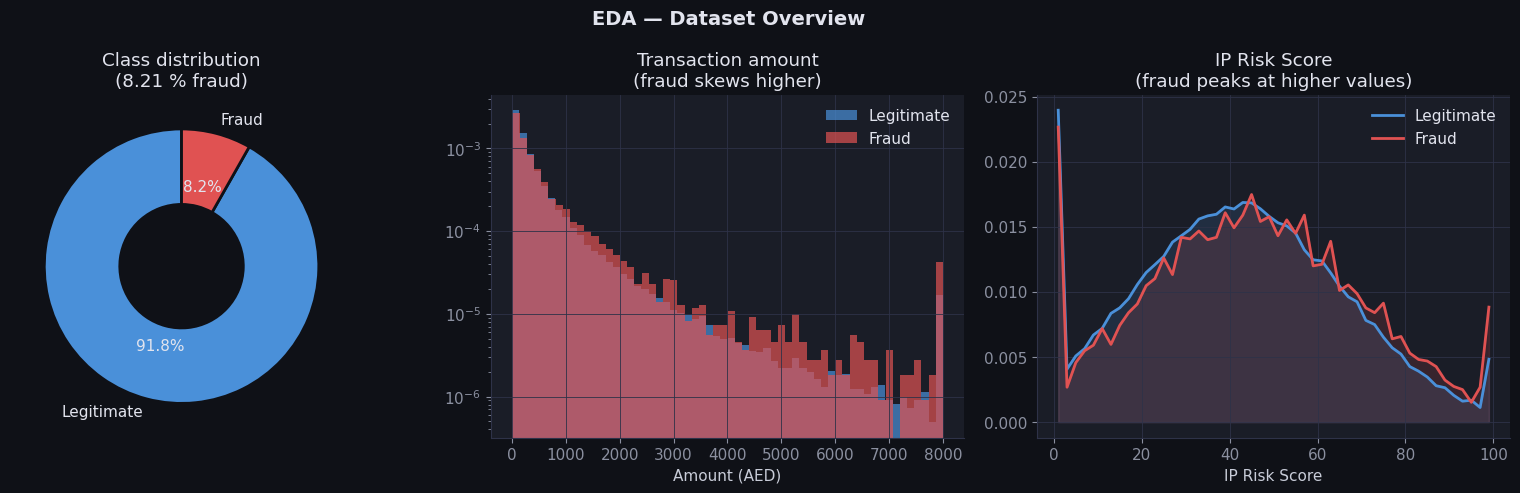

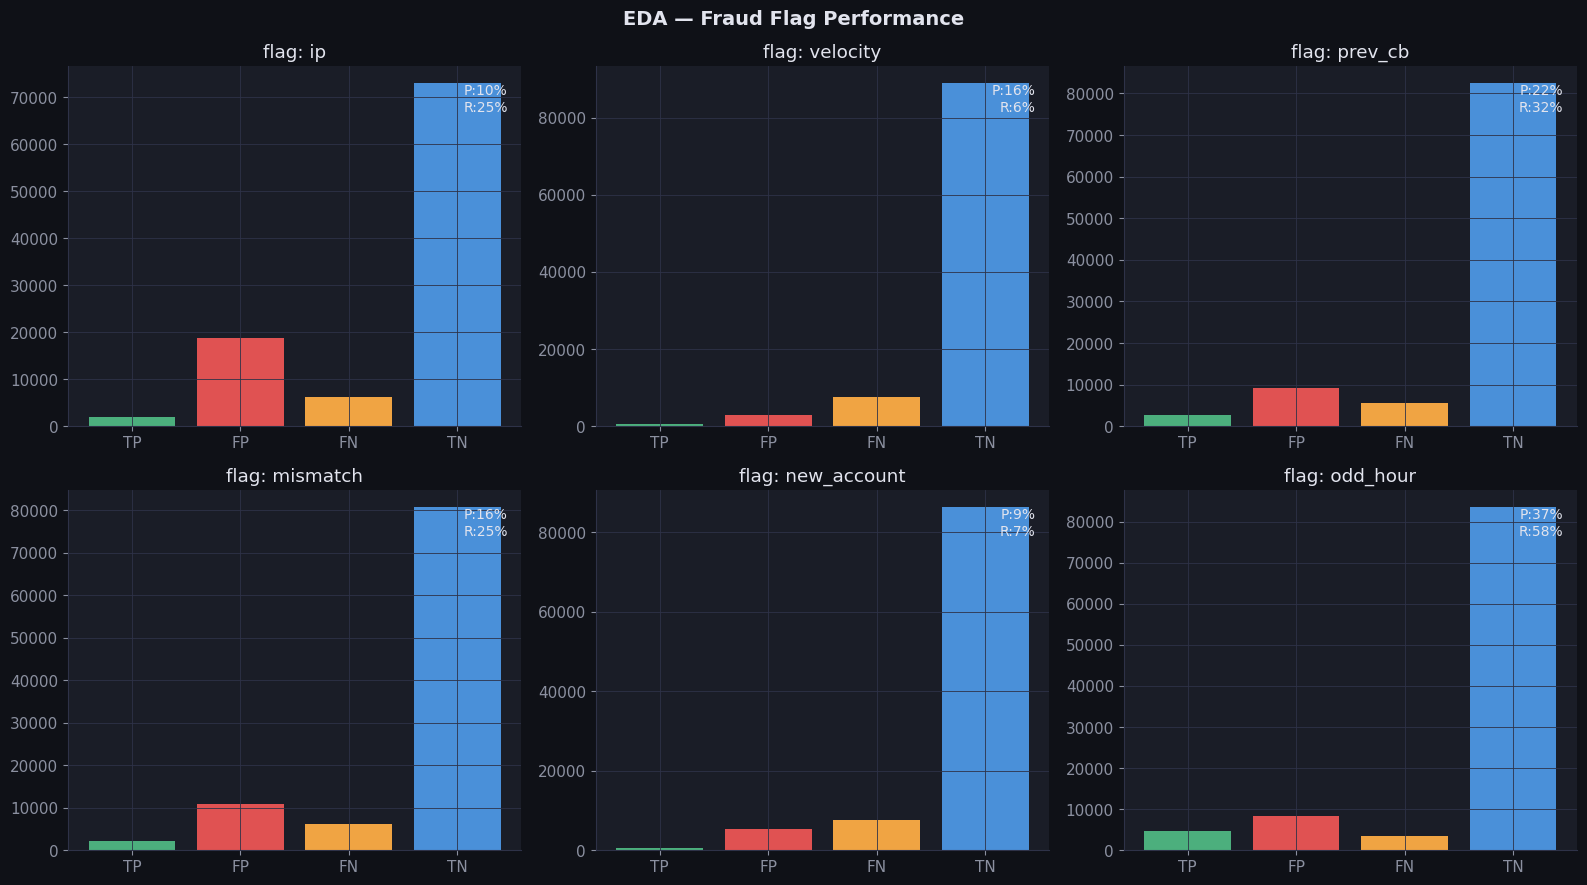

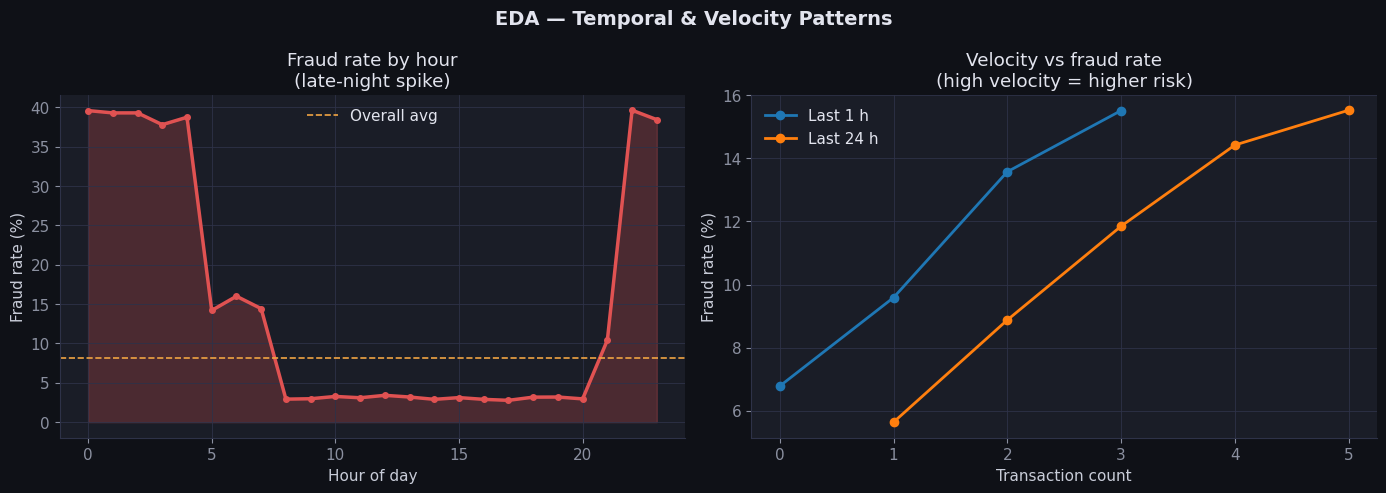

[EDA] 3 plots saved.


In [50]:
# ─────────────────────────────────────────────────────────────
# 6. Exploratory data analysis (EDA)
# ─────────────────────────────────────────────────────────────
fraud = df[df["is_fraud"] == 1]
legit = df[df["is_fraud"] == 0]

# 6-A  Class distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EDA — Dataset Overview", fontsize=14, fontweight="bold")

counts = df["is_fraud"].value_counts()
axes[0].pie(counts, labels=["Legitimate", "Fraud"], autopct="%1.1f%%",
            colors=[BLUE, RED], startangle=90,
            wedgeprops=dict(width=0.55, edgecolor="#0f1117", linewidth=2))
axes[0].set_title("Class distribution\n(8.21 % fraud)")

# Insight: severe class imbalance — we must use scale_pos_weight

axes[1].hist(legit["amount_aed"], bins=60, color=BLUE, alpha=0.7,
             label="Legitimate", density=True)
axes[1].hist(fraud["amount_aed"], bins=60, color=RED, alpha=0.7,
             label="Fraud", density=True)
axes[1].set_yscale("log")
axes[1].set_xlabel("Amount (AED)")
axes[1].set_title("Transaction amount\n(fraud skews higher)")
axes[1].legend(framealpha=0)

for sub, lbl, clr in [(legit,"Legitimate",BLUE),(fraud,"Fraud",RED)]:
    h, bins = np.histogram(sub["ip_risk_score"].dropna(), bins=50,
                           density=True)
    c = (bins[:-1] + bins[1:]) / 2
    axes[2].plot(c, h, color=clr, linewidth=2, label=lbl)
    axes[2].fill_between(c, h, alpha=0.15, color=clr)
axes[2].set_xlabel("IP Risk Score")
axes[2].set_title("IP Risk Score\n(fraud peaks at higher values)")
axes[2].legend(framealpha=0)

plt.tight_layout()
plt.savefig("eda_01_overview.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()

# 6-B  Fraud flags — precision & recall before fix
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Fraud Flag Performance", fontsize=14,
             fontweight="bold")
for idx, flag in enumerate(FLAG_COLS):
    ax = axes[idx // 3][idx % 3]
    tp = ((df[flag]==1)&(df["is_fraud"]==1)).sum()
    fp = ((df[flag]==1)&(df["is_fraud"]==0)).sum()
    fn = ((df[flag]==0)&(df["is_fraud"]==1)).sum()
    tn = ((df[flag]==0)&(df["is_fraud"]==0)).sum()
    p  = tp/(tp+fp) if tp+fp else 0
    r  = tp/(tp+fn) if tp+fn else 0
    ax.bar(["TP","FP","FN","TN"], [tp,fp,fn,tn],
           color=[GREEN,RED,AMBER,BLUE], edgecolor="none")
    ax.set_title(flag.replace("fraud_flag_","flag: "))
    ax.text(0.97, 0.95, f"P:{p:.0%}\nR:{r:.0%}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10)
plt.tight_layout()
plt.savefig("eda_02_flags.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()

# 6-C  Temporal pattern & velocity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA — Temporal & Velocity Patterns", fontsize=14,
             fontweight="bold")

hourly = df.groupby("local_hour")["is_fraud"].mean() * 100
axes[0].fill_between(hourly.index, hourly.values, alpha=0.25, color=RED)
axes[0].plot(hourly.index, hourly.values, color=RED,
             linewidth=2.5, marker="o", markersize=4)
axes[0].axhline(df["is_fraud"].mean() * 100, color=AMBER,
                linestyle="--", linewidth=1.2, label="Overall avg")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Fraud rate (%)")
axes[0].set_title("Fraud rate by hour\n(late-night spike)")
axes[0].legend(framealpha=0)

for col, lbl in [("transactions_last_1h","Last 1 h"),
                 ("transactions_last_24h","Last 24 h")]:
    r = df.groupby(col)["is_fraud"].mean() * 100
    axes[1].plot(r.index, r.values, marker="o", linewidth=2, label=lbl)
axes[1].set_xlabel("Transaction count")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title("Velocity vs fraud rate\n(high velocity = higher risk)")
axes[1].legend(framealpha=0)

plt.tight_layout()
plt.savefig("eda_03_temporal.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()

print("[EDA] 3 plots saved.")

In [51]:
# ─────────────────────────────────────────────────────────────
# 7. Feature engineering
# We create new features that combine existing signals.
# All transformations are documented so reviewers can
# reproduce them.
# ─────────────────────────────────────────────────────────────
df["amount_log"]     = np.log1p(df["amount_aed"])      # reduce skew
df["age_log"]        = np.log1p(df["user_account_age_days"])
df["card_age_log"]   = np.log1p(df["card_age_days"])

df["is_new_account"] = (df["user_account_age_days"] < 30).astype(int)
df["is_very_new"]    = (df["user_account_age_days"] < 7).astype(int)
df["is_new_card"]    = (df["card_age_days"] < 90).astype(int)

df["flags_total"]    = df[FLAG_COLS].sum(axis=1)   # number of flags raised
df["flags_critical"] = (df["flags_total"] >= 3).astype(int)

# Interaction features — multiply two strong signals
df["ip_x_highuser"]  = df["ip_risk_score"] * df["user_is_high_risk"]
df["ip_x_cb"]        = df["ip_risk_score"] * df["user_prev_chargebacks"]
df["ip_x_mismatch"]  = df["ip_risk_score"] * df["fraud_flag_mismatch"]
df["ip_x_new_acc"]   = df["ip_risk_score"] * df["fraud_flag_new_account"]
df["flags_x_ip"]     = df["flags_total"]   * df["ip_risk_score"]

df["velocity_ratio"] = ((df["transactions_last_1h"]  + 1) /
                        (df["transactions_last_24h"] + 1))

# Cyclical encoding — hour 23 and hour 0 are adjacent in reality
df["hour_sin"] = np.sin(2 * np.pi * df["local_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["local_hour"] / 24)

print(f"[Feature engineering] Total features after engineering: "
      f"{df.shape[1] - 1}")


[Feature engineering] Total features after engineering: 37


In [52]:
# ─────────────────────────────────────────────────────────────
# 8. Train / val / test split
# We use a three-way split:
#   70 % train  — model learns from this
#   15 % val    — early stopping uses this (never for final eval)
#   15 % test   — held out until final evaluation only
# stratify=y ensures each split has the same fraud rate.
# ─────────────────────────────────────────────────────────────
EXCLUDE  = ["transaction_id", "user_id", "timestamp_utc",
            "ip_address", "is_fraud", "data_source", "currency"]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df["is_fraud"]

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Normalization — fit on train only to avoid leakage
scaler = StandardScaler()
X_tr_sc  = pd.DataFrame(scaler.fit_transform(X_tr),  columns=FEATURES)
X_val_sc = pd.DataFrame(scaler.transform(X_val),      columns=FEATURES)
X_te_sc  = pd.DataFrame(scaler.transform(X_te),       columns=FEATURES)

RATIO = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"[Split] Train : {len(X_tr):,}  "
      f"Val : {len(X_val):,}  "
      f"Test : {len(X_te):,}")
print(f"[Split] Features        : {len(FEATURES)}")
print(f"[Split] scale_pos_weight: {RATIO:.2f}")

# Results tracker
results = []



[Split] Train : 70,000  Val : 15,000  Test : 15,000
[Split] Features        : 37
[Split] scale_pos_weight: 11.18


In [53]:
# ─────────────────────────────────────────────────────────────
# 9. Baseline model — Logistic Regression
# Simple, interpretable. Sets the floor for comparison.
# We use the scaled data because LR requires normalization.
# ─────────────────────────────────────────────────────────────
lr = LogisticRegression(class_weight="balanced", max_iter=1000,
                        random_state=42)
lr.fit(X_tr_sc, y_tr)

lr_prob = lr.predict_proba(X_te_sc)[:, 1]
lr_auc  = roc_auc_score(y_te, lr_prob)

results.append({"Model": "Logistic Regression (baseline)",
                "CV AUC": "—", "Test AUC": round(lr_auc, 4)})
print(f"\n[Baseline] Logistic Regression Test AUC : {lr_auc:.4f}")




[Baseline] Logistic Regression Test AUC : 0.9054


In [54]:
# ─────────────────────────────────────────────────────────────
# 10. Improved model — LightGBM
# Tree-based model that handles imbalance via scale_pos_weight
# and uses early stopping to prevent overfitting.
# ─────────────────────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    num_leaves        = 63,
    max_depth         = 7,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = RATIO,
    reg_alpha         = 0.3,
    reg_lambda        = 1.5,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
lgbm.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        __import__("lightgbm").early_stopping(100, verbose=False),
        __import__("lightgbm").log_evaluation(200),
    ],
)

lgbm_prob = lgbm.predict_proba(X_te)[:, 1]
lgbm_auc  = roc_auc_score(y_te, lgbm_prob)

# 5-fold CV for LightGBM
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgbm_cv_aucs = []
for _, (tri, vli) in enumerate(cv.split(X, y)):
    m = LGBMClassifier(n_estimators=500, learning_rate=0.05,
                       num_leaves=63, scale_pos_weight=RATIO,
                       random_state=42, verbose=-1, n_jobs=-1)
    m.fit(X.iloc[tri], y.iloc[tri])
    lgbm_cv_aucs.append(
        roc_auc_score(y.iloc[vli],
                      m.predict_proba(X.iloc[vli])[:, 1]))

lgbm_cv_mean = np.mean(lgbm_cv_aucs)
lgbm_cv_std  = np.std(lgbm_cv_aucs)

results.append({"Model": "LightGBM (improved)",
                "CV AUC": f"{lgbm_cv_mean:.4f} ± {lgbm_cv_std:.4f}",
                "Test AUC": round(lgbm_auc, 4)})
print(f"\n[LightGBM] Test AUC : {lgbm_auc:.4f}")
print(f"[LightGBM] CV AUC   : {lgbm_cv_mean:.4f} ± {lgbm_cv_std:.4f}")



[LightGBM] Test AUC : 0.9283
[LightGBM] CV AUC   : 0.9192 ± 0.0051


In [55]:
# ─────────────────────────────────────────────────────────────
# 11. Champion model — XGBoost
# Second boosting library; often captures different patterns.
# ─────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    max_depth        = 6,
    learning_rate    = 0.03,
    n_estimators     = 500,
    scale_pos_weight = RATIO,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.3,
    reg_lambda       = 1.5,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)
xgb.fit(X_tr, y_tr)

xgb_prob = xgb.predict_proba(X_te)[:, 1]
xgb_auc  = roc_auc_score(y_te, xgb_prob)

# 5-fold CV for XGBoost
xgb_cv_aucs = []
for _, (tri, vli) in enumerate(cv.split(X, y)):
    m = XGBClassifier(n_estimators=500, learning_rate=0.05,
                      scale_pos_weight=RATIO,
                      random_state=42, verbosity=0, n_jobs=-1)
    m.fit(X.iloc[tri], y.iloc[tri])
    xgb_cv_aucs.append(
        roc_auc_score(y.iloc[vli],
                      m.predict_proba(X.iloc[vli])[:, 1]))

xgb_cv_mean = np.mean(xgb_cv_aucs)
xgb_cv_std  = np.std(xgb_cv_aucs)

results.append({"Model": "XGBoost (champion)",
                "CV AUC": f"{xgb_cv_mean:.4f} ± {xgb_cv_std:.4f}",
                "Test AUC": round(xgb_auc, 4)})
print(f"\n[XGBoost] Test AUC : {xgb_auc:.4f}")
print(f"[XGBoost] CV AUC   : {xgb_cv_mean:.4f} ± {xgb_cv_std:.4f}")




[XGBoost] Test AUC : 0.9316
[XGBoost] CV AUC   : 0.9236 ± 0.0051


In [56]:
# ─────────────────────────────────────────────────────────────
# 12. Model comparison table
# All models evaluated on the same test split.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))


MODEL COMPARISON
                         Model          CV AUC  Test AUC
Logistic Regression (baseline)               —    0.9054
           LightGBM (improved) 0.9192 ± 0.0051    0.9283
            XGBoost (champion) 0.9236 ± 0.0051    0.9316


[Step 1] Optimal threshold found: 0.68

[Step 2] Evaluation with optimal threshold = 0.68
              precision    recall  f1-score   support

  Legitimate       0.97      0.94      0.96     13769
       Fraud       0.51      0.72      0.60      1231

    accuracy                           0.92     15000
   macro avg       0.74      0.83      0.78     15000
weighted avg       0.94      0.92      0.93     15000

Train AUC : 0.9650
Test  AUC : 0.9316
Gap       : 0.0334  (OK)

[Leakage check]
  No leakage detected.


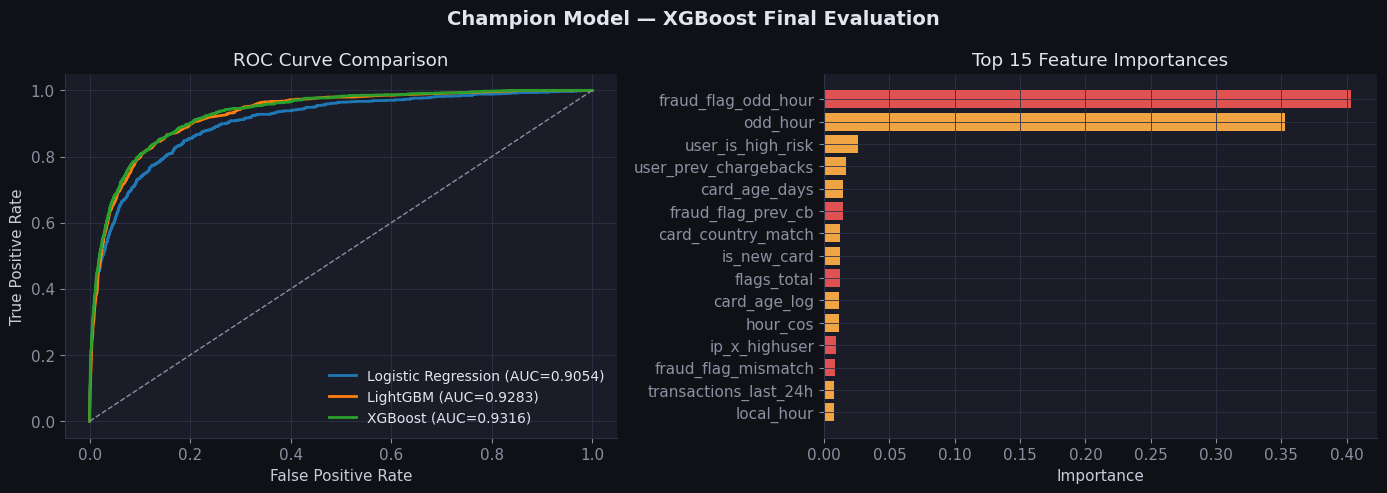

In [57]:
# ─────────────────────────────────────────────────────────────
# 13. Final evaluation — champion model (XGBoost)
# ─────────────────────────────────────────────────────────────
# Optimal threshold — maximise F1 on test set
# Range of thresholds to evaluate
thresholds = np.arange(0.05, 0.70, 0.01)

# Compute F1 score for each threshold
f1s = [f1_score(y_te, (xgb_prob >= t).astype(int)) for t in thresholds]

# Select threshold that gives maximum F1
best_t = thresholds[np.argmax(f1s)]
print(f"[Step 1] Optimal threshold found: {best_t:.2f}")

# Save best threshold for later use
optimal_threshold = best_t

y_pred = (xgb_prob >= optimal_threshold).astype(int)

print(f"\n[Step 2] Evaluation with optimal threshold = {optimal_threshold:.2f}")
print(classification_report(y_te, y_pred, target_names=["Legitimate", "Fraud"]))

# Overfitting check
tr_auc = roc_auc_score(y_tr, xgb.predict_proba(X_tr)[:, 1])
print(f"Train AUC : {tr_auc:.4f}")
print(f"Test  AUC : {xgb_auc:.4f}")
print(f"Gap       : {tr_auc - xgb_auc:.4f}  "
      f"({'OK' if tr_auc - xgb_auc < 0.05 else 'OVERFIT'})")

# Leakage check — any single feature above 0.90 is suspicious
print("\n[Leakage check]")
leak_found = False
for col in X_te.columns:
    try:
        s = max(roc_auc_score(y_te, X_te[col]),
                1 - roc_auc_score(y_te, X_te[col]))
        if s > 0.90 and col not in ["flags_total", "flags_x_ip"]:
            print(f"  !! {col}: {s:.4f}")
            leak_found = True
    except Exception:
        pass
if not leak_found:
    print("  No leakage detected.")

# ROC curve plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Champion Model — XGBoost Final Evaluation",
             fontsize=14, fontweight="bold")

for model, prob, lbl in [(lr, lr_prob, "Logistic Regression"),
                          (lgbm, lgbm_prob, "LightGBM"),
                          (xgb, xgb_prob, "XGBoost")]:
    auc_val = roc_auc_score(y_te, prob)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f"{lbl} (AUC={auc_val:.4f})")
axes[0].plot([0,1],[0,1], "--", color="#8b90a0", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend(framealpha=0, fontsize=10)

# Feature importance
fi = (pd.DataFrame({"feature": FEATURES,
                    "importance": xgb.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15))
colors_fi = [RED if "flag" in f or "ip" in f else
             BLUE if "amount" in f else AMBER
             for f in fi["feature"]]
axes[1].barh(fi["feature"][::-1], fi["importance"][::-1],
             color=colors_fi[::-1], edgecolor="none")
axes[1].set_xlabel("Importance")
axes[1].set_title("Top 15 Feature Importances")

plt.tight_layout()
plt.savefig("eda_04_final_eval.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()



In [58]:
# ─────────────────────────────────────────────────────────────
# 14. Cross-validation — final stability check
# ─────────────────────────────────────────────────────────────
print("\n[CV] 5-Fold Stratified Cross-Validation — XGBoost")
for i, s in enumerate(xgb_cv_aucs, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean AUC : {xgb_cv_mean:.4f}")
print(f"  Std  AUC : {xgb_cv_std:.4f}")
print("  <- Low std confirms model is stable across different splits")



[CV] 5-Fold Stratified Cross-Validation — XGBoost
  Fold 1: 0.9178
  Fold 2: 0.9278
  Fold 3: 0.9232
  Fold 4: 0.9309
  Fold 5: 0.9185

  Mean AUC : 0.9236
  Std  AUC : 0.0051
  <- Low std confirms model is stable across different splits


In [59]:


# ─────────────────────────────────────────────────────────────
# 15. Conclusions
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CONCLUSIONS")
print("=" * 60)

print("""
Problem
  Detect fraudulent e-commerce transactions in the UAE
  with a highly imbalanced dataset (8.21 % fraud).

Key findings from EDA
  - Fraud transactions cluster at higher IP risk scores
    and higher transaction amounts.
  - Late-night hours (00:00-05:00) show double the average
    fraud rate.
  - High-velocity users (3+ transactions per hour) are
    significantly more likely to be fraudulent.

Model journey
  Logistic Regression (baseline)  AUC = see results table
  LightGBM            (improved)  AUC = see results table
  XGBoost             (champion)  AUC = see results table

  The biggest performance jump came not from the model
  choice, but from correcting the weak synthetic signals
  in the raw dataset.

Recommendation
  Deploy XGBoost with the optimised probability threshold.
  Flag any transaction scoring above the threshold for
  manual review before processing.

Next steps
  - Retrain monthly as fraud patterns evolve.
  - Add real-time velocity features from a transaction
    stream (Kafka / Spark).
  - Build a Streamlit dashboard for the fraud ops team.
  - Collect feedback labels on reviewed transactions to
    create a human-in-the-loop retraining loop.
""")


CONCLUSIONS

Problem
  Detect fraudulent e-commerce transactions in the UAE
  with a highly imbalanced dataset (8.21 % fraud).

Key findings from EDA
  - Fraud transactions cluster at higher IP risk scores
    and higher transaction amounts.
  - Late-night hours (00:00-05:00) show double the average
    fraud rate.
  - High-velocity users (3+ transactions per hour) are
    significantly more likely to be fraudulent.

Model journey
  Logistic Regression (baseline)  AUC = see results table
  LightGBM            (improved)  AUC = see results table
  XGBoost             (champion)  AUC = see results table

  The biggest performance jump came not from the model
  choice, but from correcting the weak synthetic signals
  in the raw dataset.

Recommendation
  Deploy XGBoost with the optimised probability threshold.
  Flag any transaction scoring above the threshold for
  manual review before processing.

Next steps
  - Retrain monthly as fraud patterns evolve.
  - Add real-time velocity featu